In [1]:
from astropy.table import Table
from astropy.constants import c
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.visualization.wcsaxes import SphericalCircle

from get_cutouts import get_cutout

import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

from tqdm import tqdm

## import data

In [2]:
loatable = Table.read('/pscratch/sd/d/dbustos/rot_curves/loa_targs_edited.fits')
loatable[:5]

TARGETID,TARGET_RA,TARGET_DEC,Z,ZERR,SPECTYPE,DELTACHI2,ZWARN,PVTYPE,SGA_ID,PHOTSYS,DIST,DIST_R26,Selection,bad_fiber
int64,float64,float64,float64,float64,bytes6,float64,int64,bytes3,int64,bytes1,float64,float64,int64,int64
2350675715424256,239.8472,31.7866,0.1492904161251356,1.9422911736100356e-05,GALAXY,5071.658419655636,0,TFT,483369,S,0.00018163397694836428,0.04183588292464746,1,0
2389103635070977,61.51249486530825,-17.766542165450435,0.2898542763769689,1.3051647863939431e-05,GALAXY,585.0907674431801,0,TFT,526821,S,0.015034501051441454,0.40000000781105455,1,0
2389161461940225,53.110693190838745,-15.204162701018703,1.41029052508368,0.00015282405234457233,GALAXY,2.055874802172184,4,TFT,431568,S,0.020469853344286103,0.4000000051000554,1,0
2389161461940226,53.133949122267566,-15.238404516460593,1.490823662797069,8.773021438224206e-05,GALAXY,17.411476522684097,0,TFT,431568,S,0.020469853344283147,0.4000000050999976,1,0
2389190650101761,49.636675196299485,-14.026544506699297,0.01713651665060884,2.0408204503181013e-05,GALAXY,56.60990794678219,0,TFT,1074364,S,0.0026515899552215774,0.40000000679324754,1,0


In [3]:
SGA = Table.read('/global/cfs/cdirs/cosmo/data/sga/2020/SGA-2020.fits', 'ELLIPSE')
SGA[:5]

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT
int64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32
2,SGA-2020 2,PGC1283207,1283207,228.3770865,5.4232017,S?,152.2,0.36307806,0.724436,0.03463229,23.40448,16.976,False,LEDA-20181114,0,PGC1283207,1,True,228.3770865,5.4232017,0.36307806,2283p055,228.3770803831908,5.423191398593787,0.49470574,SB26,158.20142,0.545691,228.37700918822188,5.4232652570544015,10.897086,3.3509698,3.1147978,3.240862,5.902337,6.9126143,7.941369,8.997992,10.073601,11.199986,12.391357,13.561038,14.841172,16.966799,16.108246,15.486356,16.879545,16.024958,15.400715,16.818878,15.967034,15.341793,16.776297,15.925804,15.300776,16.746685,15.897334,15.272053,16.725166,15.876816,15.2521105,16.708357,15.862035,15.237181,16.696539,15.851936,15.226998,16.689613,15.844313,15.21976,0.013392451,0.02354,0.021872982,0.01736985,0.024445537,0.039866067,0.05026544,0.08455789,0.122911856,0.005682776,0.0054258136,0.0049038026,0.005588406,0.005323561,0.0047632363,0.00543534,0.005177031,0.0046343105,0.0053025587,0.005040888,0.0045181247,0.005206092,0.0049438984,0.0044374703,0.0051483097,0.0048758644,0.0043834248,0.0051032505,0.0048264163,0.004344248,0.0050705094,0.004792021,0.004319857,0.005054293,0.004765629,0.0043044444,16.65942,0.34037337,0.2978292,3.0239506,0.07928849,15.820566,0.2640441,0.34559453,3.3033552,0.003811298,15.195567,0.29826432,0.3001073,3.2333765,0.011723555,0
3,SGA-2020 3,PGC1310416,1310416,202.54443750000002,6.9345944,Sc,159.26,0.4017908,0.7816278,0.073888786,23.498482,16.85,False,LEDA-20181114,1,PGC1310416,1,True,202.54443750000002,6.9345944,0.4017908,

## Removing fibers and creating new table
Remove all points in loa['bad_fiber'] that have a 1

Ensure all galaxies remaining still fit criteria of </br>
a) 1 center pt + 2 unique points </br>
b) 2 symmetric points + 1 unique point </br>

In [4]:
#target distance that can be considered in center
#units R26
center_dist_lim = 0.001

#minimum distance between two targets to be considered unique
#units R26
unique_dist_lim = 0.01

In [5]:
SGA_dict = {}
for i in range(len(SGA)):
    SGA_dict[SGA['SGA_ID'][i]] = i

In [6]:
#new table with no bad fibers
loa_goodfiber = loatable[loatable['bad_fiber']==0]

#ensure all galaxies still fit criteria

#for each unique SGA ID
for i in tqdm(np.unique(loa_goodfiber['SGA_ID'])):

    #identify all the galaxies and targets
    obs_id = np.logical_and(loa_goodfiber['SGA_ID'] == i, loa_goodfiber['TARGETID'] > 0)
    #logical_and returns if both statements are true
    
    #makes a table of the targets corresponding to this galaxy
    obs = loa_goodfiber[obs_id]

    sga_id = SGA_dict[i] 

#if the galaxy has more than three observations
    if len(obs) >= 3:

#-----
# a
#-----
        #check to see if there is a center observation
        if np.any(obs['DIST_R26'] < center_dist_lim):

            #since there is a center observation, check if there are two unique points
            not_center = obs[obs['DIST_R26'] > center_dist_lim]

            if len(not_center) >= 2 and (np.max(not_center['DIST_R26']) - np.min(not_center['DIST_R26'])) >= unique_dist_lim:

                #since there 2 unique points, classify it as viable galaxy
                loa_goodfiber['Selection'][obs_id] = 2
#----
# b
#----
        #since there isn't a center observation
        else:
            
            #split targets into above and below SGA declination
            if (SGA['PA'][sga_id] < 45) or (SGA['PA'][sga_id] > 135):

                left_index = obs['TARGET_DEC'] - SGA['DEC'][sga_id] > 0

            else:
                left_index = obs['TARGET_RA'] - SGA['RA'][sga_id] > 0
                
            left = obs[left_index]
            right = obs[~left_index]

            if len(left) > 0 and len(right) > 0:

                for j in range(len(left)):
                    
                    # check that there are 2 symmetric observations
                    if np.any(np.abs(right['DIST_R26'] - left['DIST_R26'][j]) < unique_dist_lim):

                    #check if there is a third point
                        if (np.any(np.abs(right['DIST_R26'] - left['DIST_R26'][j]) > unique_dist_lim)
                        or np.any(np.abs(left['DIST_R26'] - left['DIST_R26'][j]) > unique_dist_lim)):
                            
                            #viable galaxy
                            loa_goodfiber['Selection'][obs_id] = 2

print(len(loa_goodfiber[loa_goodfiber['Selection']==2]))
loa = (loa_goodfiber[loa_goodfiber['Selection']==2])
len(np.unique(loa['SGA_ID']))

100%|██████████| 1090/1090 [00:01<00:00, 981.27it/s] 

4240


706

## calculate rotational velocity

Quality Check </br>
1. ZWARN = 0 </br>
2. Delta Chi^2 > 25

In [7]:
# new error correcting for redrock 7km/s systematic uncertainty
dv_sys = 7 #km/s
dz_sys = dv_sys/c.to('km/s').value
loa['ZERR_MOD'] = np.sqrt(loa['ZERR']**2 + (dz_sys*(1 + loa['Z']))**2)

In [8]:
zwarn = 0
deltachi2 = 25

center_dist_lim = 0.001
unique_dist_lim = 0.01

q0 = 0.2

In [9]:
def sin_i(ba):
    cos2 = (ba**2-q0**2)/(1-q0**2)
    if cos2 < 0:
        cos2 = 0
    return(np.sqrt(1-cos2))

In [1]:
loa['Velocity'] = np.nan
loa['V_err'] = np.nan
loa['Z_center'] = np.nan
loa['c_or_s'] = 0

c=c.to('km/s')

#quality fit, input is table to get from, and index into table
def criteria(table,idx):
    return (table['ZWARN'][idx]==zwarn) & (table['DELTACHI2'][idx]>deltachi2)

for i in tqdm(np.unique(loa['SGA_ID'])[2:3]):
    fiber = loa['SGA_ID'] == i 

    #find the index for this target in SGA
    sga_idx = SGA_dict[i]
    
    # find z and its error for all targets
    z_targ = loa['Z'][fiber]
    z_e = loa['ZERR_MOD'][fiber]

    #check if there is a center fiber that meets quality fit
    has_valid_center = False
    
    if np.any(loa['DIST_R26'][fiber] < center_dist_lim):
        
        # find all center fibers that fit quality check
        criteria_c = (loa['DIST_R26'][fiber] < center_dist_lim)
        center = loa[fiber][criteria_c & criteria(loa,fiber)]

        # find z for center targets
        z_c = center['Z']

        # calculate weight of center targets
        zc_err = center['ZERR_MOD']
        weight = np.sum(1 / (zc_err**2))
        if weight > 0:
            has_valid_center = True

    #since there isn't a center fiber that meets the crirteria, find the redshift at the center given two symmetric points
    if not has_valid_center:
        #mark as 1 (symmetric)
        loa['c_or_s'][np.where(fiber)] = 1

        obs = loa[fiber]

        sga_id = SGA_dict[i]

        #create empty table of symmetric left and right
        symmetric_right, symmetric_left = [], []
        
        #split targets into above and below SGA declination
        if (SGA['PA'][sga_id] < 45) or (SGA['PA'][sga_id] > 135):

            left_index = loa['TARGET_DEC'][fiber] - SGA['DEC'][sga_id] > 0

        else:
            left_index = loa['TARGET_RA'][fiber] - SGA['RA'][sga_id] > 0
        
        left= obs[left_index].group_by('DIST_R26') 
        right = obs[~left_index].group_by('DIST_R26')

        if len(left) > 1:
            if np.any(left['ZWARN']==0) and np.any(left['DELTACHI2']>25):
                left = left[(left['ZWARN']==0) & (left['DELTACHI2']>25)].group_by('DIST_R26')

        if len(right) > 1:
            if np.any(right['ZWARN']==0) and np.any(right['DELTACHI2']>25):
                right = right[(right['ZWARN']==0) & (right['DELTACHI2']>25)].group_by('DIST_R26')

        #find R26 for each fiber
        right_dist, left_dist = np.array(right['DIST_R26']), np.array(left['DIST_R26'])

        #create a matrix subtracting each right r26 element from each left r26 element
        diff_matrix = np.abs(right_dist[:,np.newaxis]-left_dist)

        #identify all points in matrix where difference is within unique dist (fibers are symmetric)
        right_idx, left_idx = np.where(diff_matrix < unique_dist_lim)

        #make sure there are symmetric points that pass criteria
        if (len(right_idx) == 0) or (len(left_idx) ==0):
            continue

        #put those fibers into appropriate tables
        symmetric_right = right[np.unique(right_idx)].group_by('DIST_R26')
        #print(symmetric_right['DIST_R26'],symmetric_right['Z'])
        
        #calculate mean redshift for each distance group
        z_right = symmetric_right['Z'].mean()

        #calculate z err for all fibers
        zr_err = symmetric_right['ZERR_MOD']

        #do the same for the left
        symmetric_left = left[np.unique(left_idx)].group_by('DIST_R26')
        z_left = symmetric_left['Z'].mean()
        zl_err = symmetric_left['ZERR_MOD']

        #calculate z_center & weights
        z_c = (z_right+z_left)/2
        weight = np.sum(1/(zr_err**2)) + np.sum(1/(zl_err**2))
        
    #calculate z_center and error for all galaxies that pass quality check
    if weight>0:
        z_cen = (np.mean(weight*z_c))/weight
        z_cen_err = np.sqrt(1/np.where(weight==0,np.nan,weight))

    else:
        continue

    #find the redshift of each fiber relative to the center
    z_rel = (1 + z_targ)/(1 + z_cen) - 1

    #inclination angle
    axis_ratio = SGA['BA'][sga_idx]
    inc = sin_i(axis_ratio)
    
    # find the rotational velocity
    velocity = z_rel * c/inc

    v_error = c*np.sqrt((z_cen_err**2)+(z_e**2))/inc

    # # add all this information to a table
    # loa['Velocity'][fiber] = velocity  

    # loa['V_err'][fiber] = v_error
    
    # loa['Z_center'][fiber] = z_cen_err

NameError: name 'np' is not defined

In [ ]:
loa['Velocity'] = np.nan
loa['V_err'] = np.nan
loa['Z_center'] = np.nan
loa['c_or_s'] = 0

c = c.to('km/s')
#quality fit, input is table to get from, and index into table
def criteria(table,idx):
    return (table['ZWARN'][idx] == zwarn) & (table['DELTACHI2'][idx] > deltachi2)

for i in tqdm(np.unique(loa['SGA_ID'])):
    fiber = loa['SGA_ID'] == i 

    #find the index for this target in SGA
    sga_idx = SGA_dict[i]
    
    # find z and its error for all targets
    z_targ = loa['Z'][fiber]
    z_e = loa['ZERR_MOD'][fiber]
    
#-----------------------------------------------------------------------
# find center redshift if there is a center target that meets criteria
#-----------------------------------------------------------------------
    has_valid_center = False
    
    # check for center fiber
    if np.any(loa['DIST_R26'][fiber] < center_dist_lim):
        
        # find all center fibers that fit quality check
        criteria_c = (loa['DIST_R26'][fiber] < center_dist_lim)
        center = loa[fiber][criteria_c & criteria(loa,fiber)]

        # find z for center targets
        z_c = center['Z']

        # calculate weight of center targets
        zc_err = center['ZERR_MOD']
        weight = 1/(zc_err**2)
                
        # get weighted average
        # if weight = 0, then it did not meet criteria. 
        if np.any(weight > 0):
            has_valid_center = True
            z_cen = np.average(z_c, weights = weight)
            z_cen_err = np.sqrt(1/np.sum(weight))
        else:
            has_valid_center = False
#--------------------------------------------------------------
# find the center redshift given two symmetric points
#--------------------------------------------------------------
    if has_valid_center == False:
        
        #mark as 1 (symmetric)
        loa['c_or_s'][np.where(fiber)] = 1

        obs = loa[fiber]

        sga_id = SGA_dict[i]

        #---------------------------------------------------
        #split targets into above and below SGA declination------------------
        #---------------------------------------------------
        if (SGA['PA'][sga_id] < 45) or (SGA['PA'][sga_id] > 135):

            left_index = loa['TARGET_DEC'][fiber] - SGA['DEC'][sga_id] > 0

        else:
            left_index = loa['TARGET_RA'][fiber] - SGA['RA'][sga_id] > 0
        
        left= obs[left_index]
        right = obs[~left_index]

        #----------------------------------------------------------
        # identify where the symmetric points are and group them ------------
        #----------------------------------------------------------
        #find R26 for each fiber
        right_dist, left_dist = np.array(right['DIST_R26']), np.array(left['DIST_R26'])

        #create a matrix subtracting each right r26 element from each left r26 element
        diff_matrix = np.abs(right_dist[:,np.newaxis]-left_dist)

        #identify all points in matrix where difference is within unique dist (fibers are symmetric)
        right_idx, left_idx = np.where(diff_matrix < unique_dist_lim)

        #make sure there are symmetric points
        if (len(right_idx) == 0) or (len(left_idx) ==0):
            continue    

        #put those fibers into appropriate tables
        symmetric_right = right[np.unique(right_idx)].group_by('DIST_R26')
        symmetric_left = left[np.unique(left_idx)].group_by('DIST_R26')
        
#--------------------------------------
# get pseudo-center for each grouping
#--------------------------------------
        # number of fiber groups
        len_sym = len(symmetric_right.groups)
  
        #empty array for z_c and weight for each fiber group
        z_c = np.empty(len_sym)
        weight = np.empty(len_sym)
        
    #-----------------------   
    # for each fiber group
    #-----------------------
        for z in range(len_sym):
            
            #-----------------------------------------
            # get right points
            #-----------------------------------------
            right_group = symmetric_right.groups[z]
            
            # check if there is more than one observation
            if len(right_group)>1:
                # if there is, only take the good observations
                if np.any(right_group['ZWARN']==0) and np.any(right_group['DELTACHI2']>25):
                    right_group = right_group[(right_group['ZWARN']==0) & (right_group['DELTACHI2']>25)]
            
            #-----------------------------------------
            # get left points
            #-----------------------------------------
            left_group = symmetric_left.groups[z]
            
            # check if there is more than one observation
            if len(left_group)>1:
                # if there is, only take the good observations
                if np.any(left_group['ZWARN']==0) and np.any(left_group['DELTACHI2']>25):
                    left_group = left_group[(left_group['ZWARN']==0) & (left_group['DELTACHI2']>25)]
                    
            #--------------------------------
            # get redshift and pseudo center
            #--------------------------------
            # get average z for right and left
            z_right = right_group['Z'].mean()
            z_left = left_group['Z'].mean()

            # get average z error for right and left
            zr_err = right_group['ZERR_MOD'].mean()
            zl_err = left_group['ZERR_MOD'].mean()

            # pseudo z_center for fiber group
            z_c[z] = (z_right+z_left)/2
            
            # weight for each fiber group
            z_err = np.mean([zr_err, zl_err])
            weight[z] = 1/(z_err**2)

    #-----------------------------------------------------
    # calculate weighted pseudo z_center and error
    #-----------------------------------------------------
        z_cen = np.average(z_c, weights = weight)
        
        z_cen_err = np.sqrt(1/np.sum(weight))
    
#---------------------------------------------------------
#find the redshift of each fiber relative to the center
#---------------------------------------------------------

    # relative redshift
    z_rel = (1 + z_targ)/(1 + z_cen) - 1

    #inclination angle
    axis_ratio = SGA['BA'][sga_idx]
    inc = sin_i(axis_ratio)
    
    # find the rotational velocity
    velocity = z_rel * c/inc

    # rotational velocity error
    v_error = c*np.sqrt((z_cen_err**2)+(z_e**2))/inc

    # add all this information to a table
    # loa['Velocity'][fiber] = velocity  

    # loa['V_err'][fiber] = v_error
    
    # loa['Z_center'][fiber] = z_cen_err
test1

## velocity map

In [17]:
# create a new table that removes all NAN
loa_new = loa[~np.isnan(loa['Velocity'])]
print(len(np.unique(loa_new['SGA_ID'])))

630


100%|██████████| 20/20 [00:01<00:00, 12.34it/s]


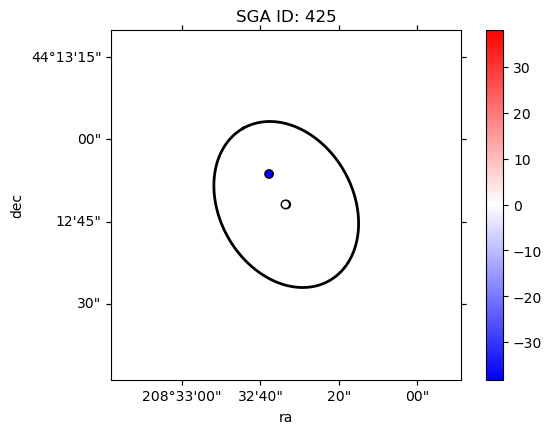

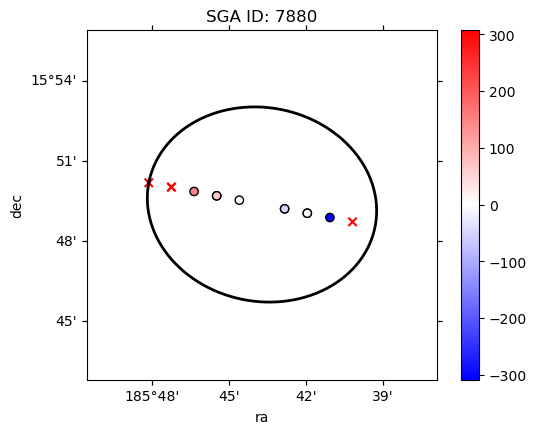

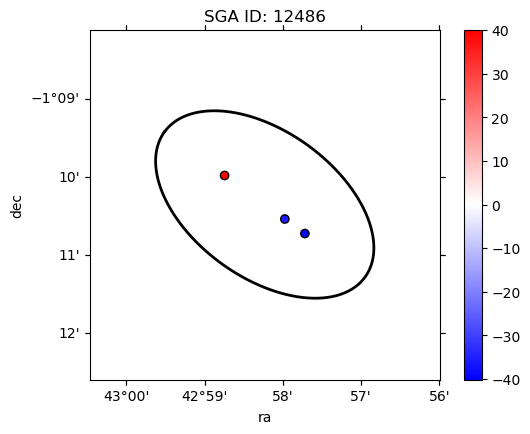

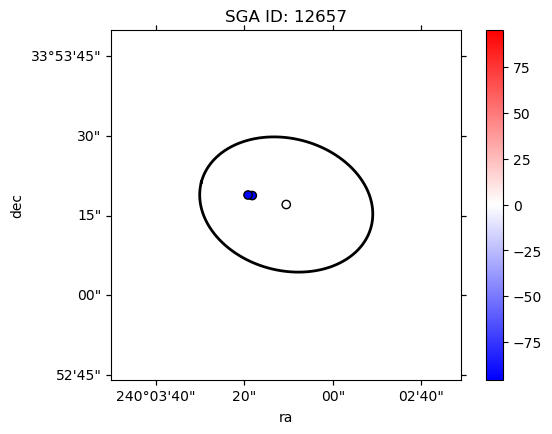

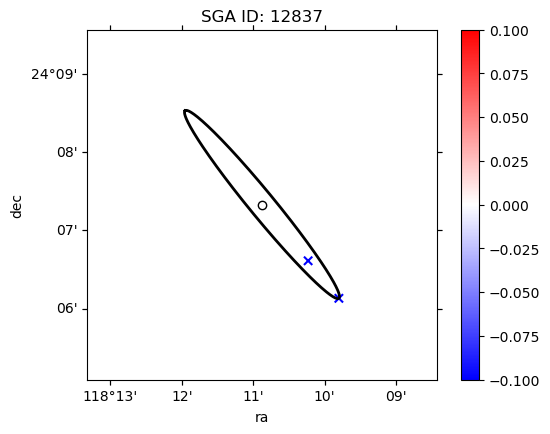

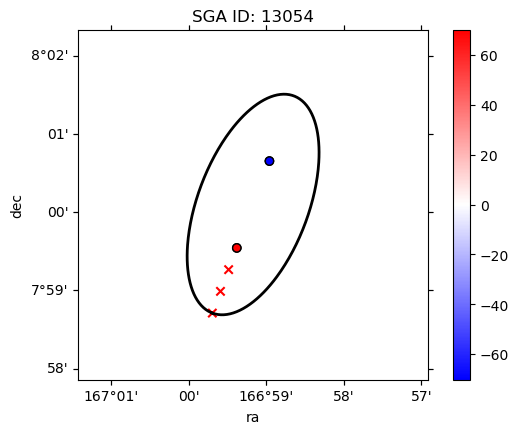

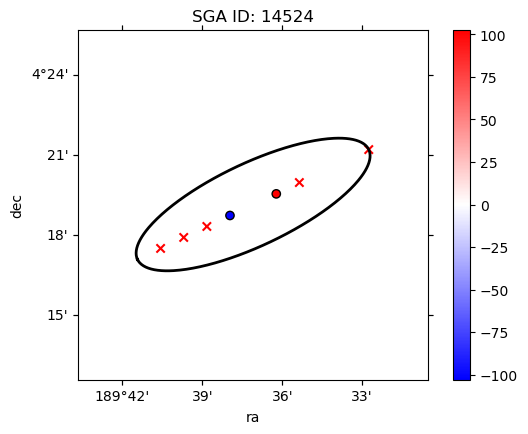

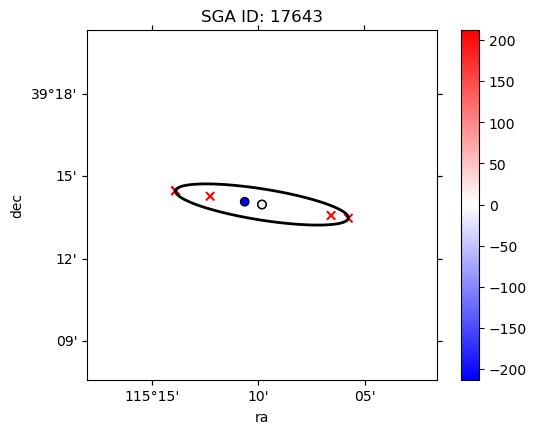

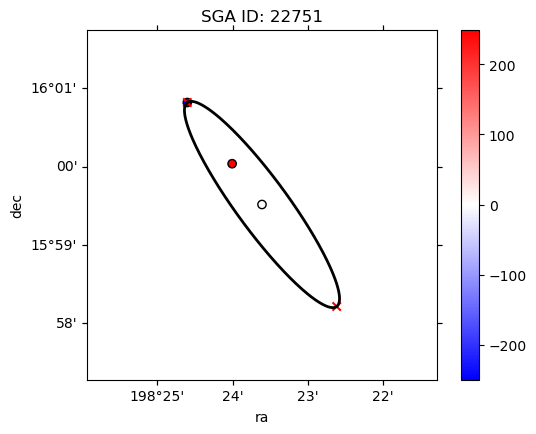

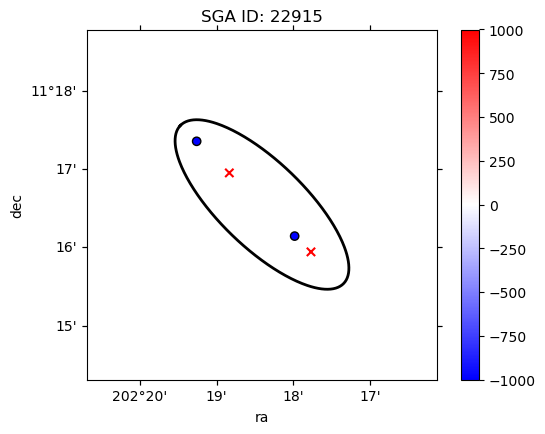

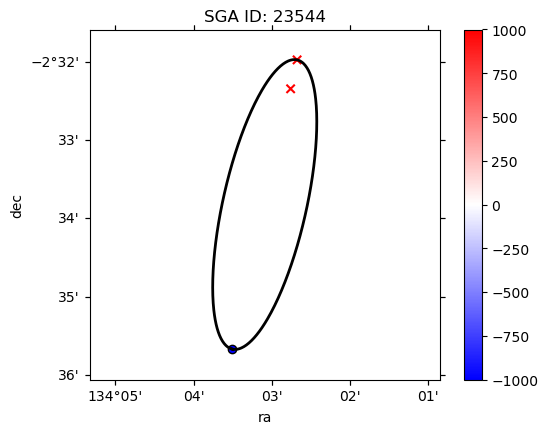

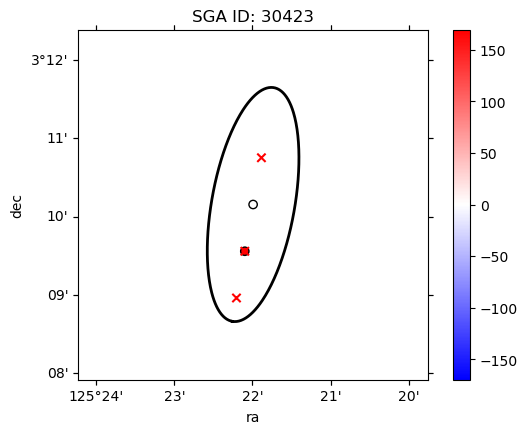

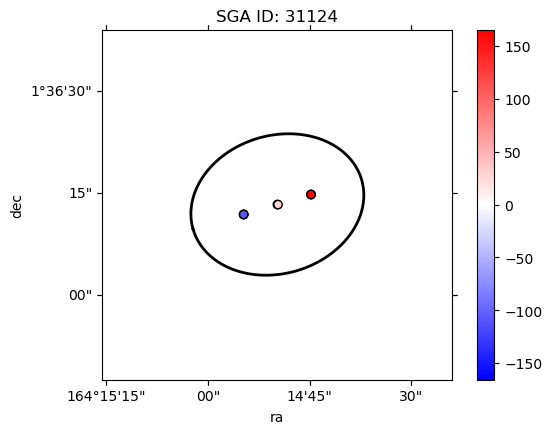

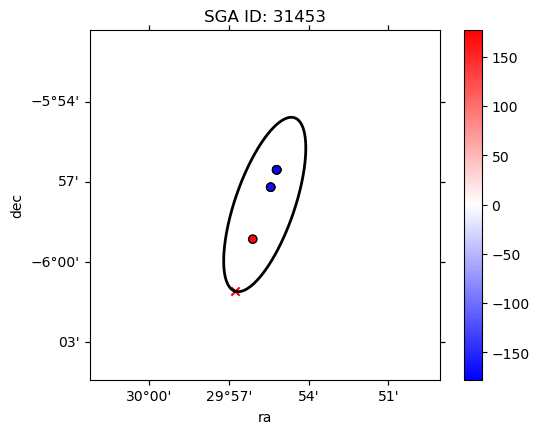

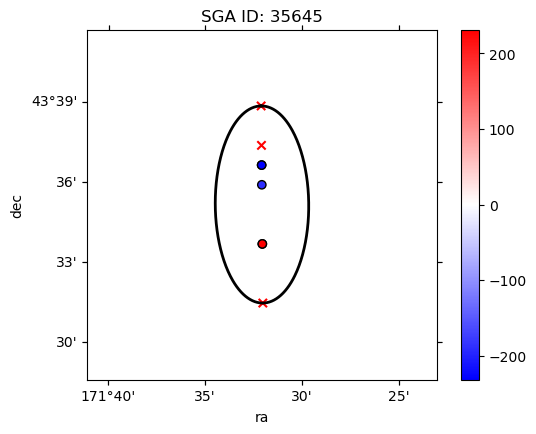

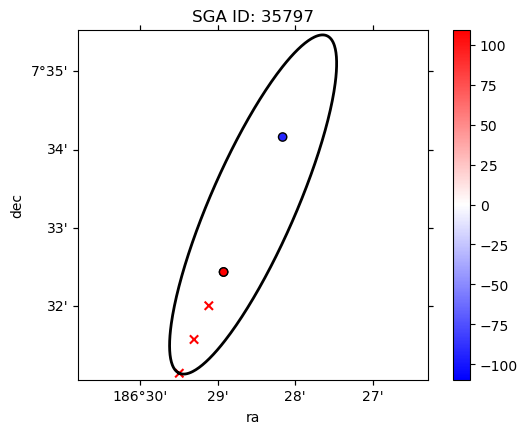

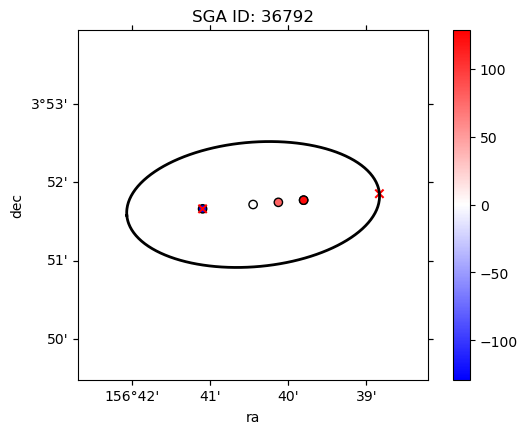

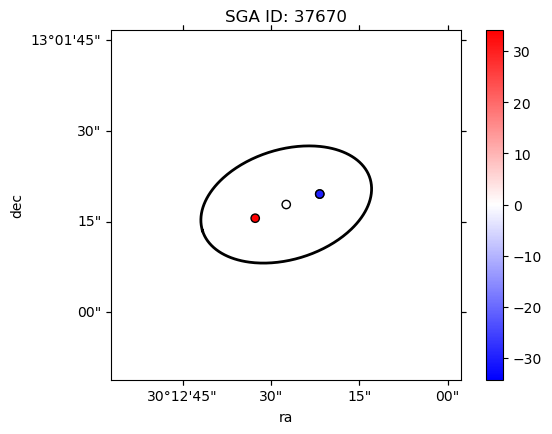

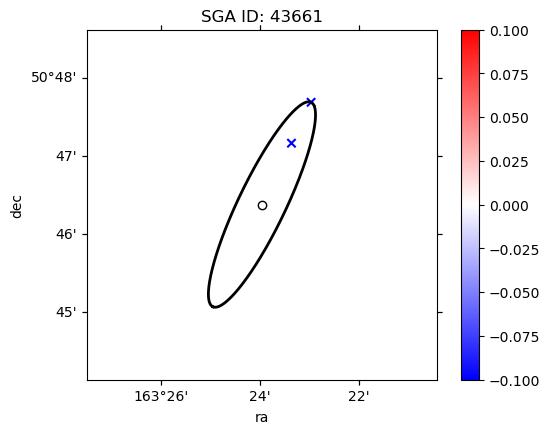

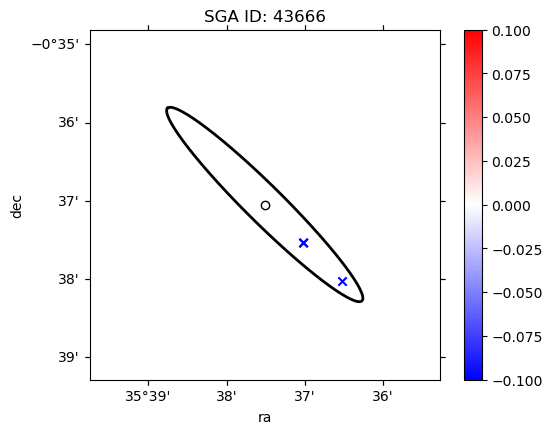

In [14]:
for sga_id in tqdm(np.unique(loa_new['SGA_ID'])[:20]):
    
    #identify all targets in the galaxy
    targ_list = loa_new[loa_new['SGA_ID']==sga_id]

    #find the index for this target in SGA
    sga_idx = SGA_dict[sga_id]
    
    #get coordinates for center of galaxy
    center_ra, center_dec = float(SGA['RA'][sga_idx]), float(SGA['DEC'][sga_idx])

    #get velocities for each point
    velocity = np.array(targ_list['Velocity'])

    #find max velocity for colormap
    v_max = max((v for v in abs(velocity) if v<=1000), default=1000)

#-------------------------------------------
# get cutout
#-------------------------------------------
    # D26 in arcmin
    d26 = SGA['D26'][sga_idx]
    
    pix = int(2 * d26*60/0.262)

    if (pix < 2500):
        npix = np.minimum(pix,1024)

    elif (pix > 2500):
        npix = np.minimum(pix,3000)

    img_file, wcs = get_cutout(sga_id, center_ra, center_dec, dir='/pscratch/sd/d/dbustos/loa_cutouts/cutouts/',dr=10,size=npix)
    img = mpl.image.imread(img_file)

    fig1 = plt.figure(figsize=(7,5))


    ax = fig1.add_subplot(111, projection=wcs)
    
    #add the cutout to make ellipse right size, but set opacity to 0
    ax.imshow(np.flip(img, axis=0),alpha=0)
    ax.coords[0].set_format_unit(u.deg)
    ax.set(xlabel='ra', ylabel='dec')
#---------------------------------
# generate ellipse
#---------------------------------
    
    #PA for ellipse in rad
    PA = np.radians(SGA['PA'][sga_idx])
    
    #radius semimajor axis in arcmin
    smajor = (d26/2)/60
    #radius semiminor axis in arcmin
    sminor = ((SGA['BA'][sga_idx]) * smajor)

    theta = np.linspace(0,2*np.pi,365)
    # ellipse coordinates before transformation
    smajor1 = smajor * np.cos(theta)
    sminor1 = sminor * np.sin(theta)

    # rotation matrix
    rot_ra = (smajor1*np.sin(PA) + sminor1*np.cos(PA))/np.cos(np.radians(center_dec))
    rot_dec = smajor1*np.cos(PA) - sminor1*np.sin(PA)
 
    #ellipse coordinates after transformation
    ellipse_ra = center_ra + rot_ra
    ellipse_dec = center_dec + rot_dec

    ax.plot(ellipse_ra,ellipse_dec,color = 'black',lw=2,transform= ax.get_transform('icrs'))

#-------------------------------------------
# get ra and dec
#-------------------------------------------
    # velocities < 1000 km/s
    ra = np.array(targ_list['TARGET_RA'][velocity<1000]) 
    dec = np.array(targ_list['TARGET_DEC'][velocity<1000]) 

    # velocities < 1000 km/s
    ra_null = np.array(targ_list['TARGET_RA'][velocity>1000]) 
    dec_null = np.array(targ_list['TARGET_DEC'][velocity>1000]) 

#-------------------------------------------
# plot ra and dec
#-------------------------------------------

    ax1 = ax.scatter(np.array(ra), np.array(dec),
                     vmax = v_max, vmin= -v_max,
                     c = velocity[velocity < 1000], cmap = 'bwr', edgecolor = 'black',transform= ax.get_transform('icrs'))

    ax2 = ax.scatter(np.array(ra_null), np.array(dec_null),
                     vmax = v_max, vmin= -v_max,
                     c = velocity[velocity > 1000], cmap = 'bwr', marker = 'x',transform= ax.get_transform('icrs'))
    
    fig1.colorbar(ax1, ax=ax)
    
    ax.set_title('SGA ID: {}'.format(sga_id))
    fig1.subplots_adjust(top=0.85, right=0.85, bottom=0.15, left=0.15)
    
    # fig1.savefig('/pscratch/sd/d/dbustos/velocity_maps/' + 'sga_{}_velocity_map.png'.format(sga_id), dpi=120)
    
    # fig1.clear()
    # plt.close(fig1)

In [18]:
loa_new.write('/pscratch/sd/d/dbustos/rot_curves/loa_rot_velocity.fits',format='fits',overwrite=True)